<a href="https://colab.research.google.com/github/ANGELARIELPLAZA/qr/blob/main/AI_Tester_QR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Información y Origen del Dataset

Para esta demostración de reconocimiento de dígitos numéricos, utilizaremos el clásico dataset **MNIST**.

* **Nombre:** MNIST (Modified National Institute of Standards and Technology)
* **Origen:** Proviene del repositorio de datasets de Keras / TensorFlow (`keras.datasets.mnist`).
* **Objetivo:** Clasificar imágenes en escala de grises de $28 \times 28$ píxeles en 10 clases de dígitos (del 0 al 9).

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Mostrar estadísticas de volumen y estado
print(f"--- Volumen del Dataset ---")
print(f"Imágenes de entrenamiento (x_train): {x_train.shape[0]} muestras de tamaño {x_train.shape[1]}x{x_train.shape[2]}")
print(f"Etiquetas de entrenamiento (y_train): {y_train.shape[0]} etiquetas")
print(f"Imágenes de prueba (x_test): {x_test.shape[0]} muestras de tamaño {x_test.shape[1]}x{x_test.shape[2]}")
print(f"Etiquetas de prueba (y_test): {y_test.shape[0]} etiquetas\n")

print(f"--- Estado y Formato de los Datos ---")
print(f"Rango de valores de píxeles: [{x_train.min()}, {x_train.max()}]")
print(f"Tipos de datos: {x_train.dtype}")
print(f"Clases únicas (dígitos a reconocer): {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Volumen del Dataset ---
Imágenes de entrenamiento (x_train): 60000 muestras de tamaño 28x28
Etiquetas de entrenamiento (y_train): 60000 etiquetas
Imágenes de prueba (x_test): 10000 muestras de tamaño 28x28
Etiquetas de prueba (y_test): 10000 etiquetas

--- Estado y Formato de los Datos ---
Rango de valores de píxeles: [0, 255]
Tipos de datos: uint8
Clases únicas (dígitos a reconocer): [0 1 2 3 4 5 6 7 8 9]


### 2. Visualización de Muestras del Dataset

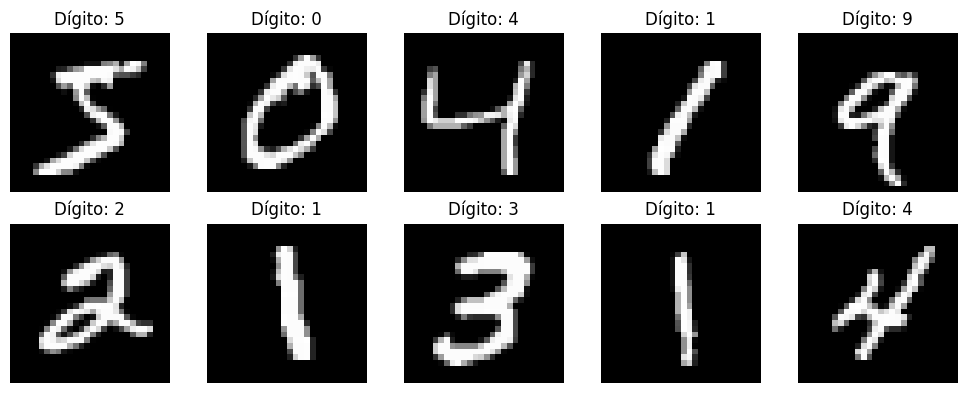

In [2]:
# Visualizar algunas imágenes de ejemplo
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Dígito: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Preprocesamiento y Entrenamiento de un Modelo Simple

Normalizaremos los valores de los píxeles al rango $[0, 1]$ y crearemos una red neuronal feed-forward sencilla.

In [3]:
# Normalización de los datos (Estado: listo para entrenar)
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0

# Construcción de un modelo secuencial simple
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Resumen del modelo
model.summary()

# Entrenamiento del modelo
history = model.fit(x_train_norm, y_train, epochs=3, validation_split=0.1, batch_size=64)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9131 - loss: 0.3125 - val_accuracy: 0.9625 - val_loss: 0.1441
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9594 - loss: 0.1417 - val_accuracy: 0.9700 - val_loss: 0.1078
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9699 - loss: 0.1007 - val_accuracy: 0.9742 - val_loss: 0.0891


### 4. Evaluación de Resultados

 PRECISIÓN GLOBAL EN PRUEBAS: 97.24%
 PÉRDIDA GLOBAL EN PRUEBAS:    0.0939

--- Reporte de Clasificación por Dígito ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.97      0.96      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



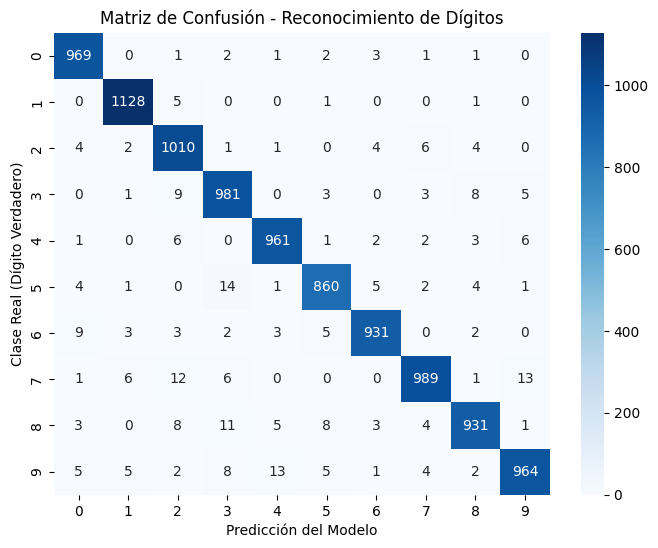

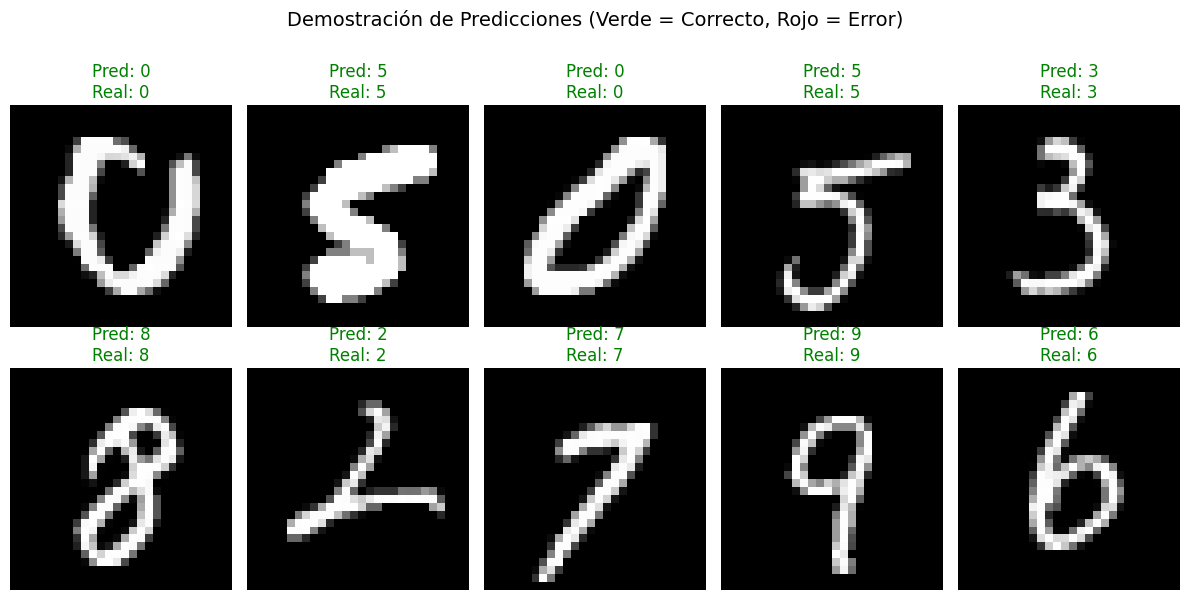

In [5]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 1. Evaluar pérdidas y precisión generales
test_loss, test_acc = model.evaluate(x_test_norm, y_test, verbose=0)
print(f"==================================================")
print(f" PRECISIÓN GLOBAL EN PRUEBAS: {test_acc * 100:.2f}%")
print(f" PÉRDIDA GLOBAL EN PRUEBAS:    {test_loss:.4f}")
print(f"==================================================\n")

# 2. Generar predicciones
y_pred_probs = model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Reporte de Clasificación Detallado
print("--- Reporte de Clasificación por Dígito ---")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# 4. Matriz de Confusión Visual
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusión - Reconocimiento de Dígitos')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Dígito Verdadero)')
plt.show()

# 5. Visualización de Predicciones del Modelo (Correctas vs Incorrectas)
plt.figure(figsize=(12, 6))
# Elegir 10 índices aleatorios del set de prueba
random_indices = np.random.choice(len(x_test), size=10, replace=False)

for idx, test_idx in enumerate(random_indices):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(x_test[test_idx], cmap='gray')
    pred_label = y_pred[test_idx]
    true_label = y_test[test_idx]

    # Color verde si es correcto, rojo si falló
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nReal: {true_label}", color=color, fontsize=12)
    plt.axis('off')

plt.suptitle('Demostración de Predicciones (Verde = Correcto, Rojo = Error)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5. Prueba el Modelo con tus Propias Imágenes

Ejecuta la siguiente celda para subir una imagen de un dígito escrito a mano desde tu computadora. El script adaptará automáticamente la imagen al formato requerido por el modelo ($28 \times 28$ píxeles en escala de grises con fondo negro) y predecirá el resultado.

Saving Captura de pantalla 2026-09-23 065339.png to Captura de pantalla 2026-09-23 065339.png


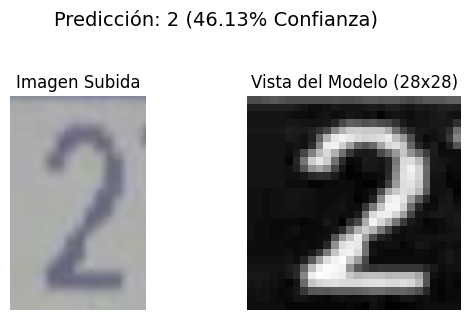

In [6]:
from google.colab import files
from PIL import Image, ImageOps
import io

# 1. Botón para subir la imagen
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Leer la imagen subida
    image_data = uploaded[filename]
    img = Image.open(io.BytesIO(image_data))

    # 3. Preprocesamiento:
    # Convertir a escala de grises ('L')
    img_gray = img.convert('L')

    # Redimensionar a 28x28 píxeles
    img_resized = img_gray.resize((28, 28))

    # Convertir a arreglo de numpy
    img_array = np.array(img_resized)

    # MNIST tiene fondo negro (0) y trazo blanco (255).
    # Si la imagen subida tiene fondo claro/blanco, la invertimos automáticamente.
    if img_array[0, 0] > 127:
        img_array = 255 - img_array

    # Normalizar valores al rango [0, 1]
    img_norm = img_array / 255.0

    # Expandir dimensiones para que coincida con la entrada del modelo: (1, 28, 28)
    img_input = np.expand_dims(img_norm, axis=0)

    # 4. Realizar la predicción con el modelo entrenado
    prediction_probs = model.predict(img_input, verbose=0)
    predicted_digit = np.argmax(prediction_probs)
    confidence = np.max(prediction_probs) * 100

    # 5. Mostrar resultados visuales
    plt.figure(figsize=(6, 3))

    # Imagen original subida
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Imagen Subida")
    plt.axis('off')

    # Imagen procesada tal como la ve el modelo
    plt.subplot(1, 2, 2)
    plt.imshow(img_norm, cmap='gray')
    plt.title(f"Vista del Modelo (28x28)")
    plt.axis('off')

    plt.suptitle(f"Predicción: {predicted_digit} ({confidence:.2f}% Confianza)", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

### 6. Subida Múltiple y Reporte Unificado de Resultados

Ejecuta la siguiente celda para subir **varias imágenes a la vez** (puedes seleccionarlas juntas en tu explorador de archivos). El modelo las analizará de forma individual y, para finalizar, consolidará todos los resultados en un reporte único.

In [ ]:
import pandas as pd
from google.colab import files
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

# 1. Botón para subir múltiples archivos
uploaded_multiple = files.upload()

# Lista para guardar el resumen de resultados
results_list = []

if len(uploaded_multiple) > 0:
    # Crear figura para mostrar el análisis individual de cada imagen
    num_images = len(uploaded_multiple)
    cols = 3
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))

    # Asegurar que axes sea siempre un array plano de la forma correcta
    if num_images == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, (filename, image_data) in enumerate(uploaded_multiple.items()):
        # 2. Cargar e interpretar la imagen
        img = Image.open(io.BytesIO(image_data))
        img_gray = img.convert('L')
        img_resized = img_gray.resize((28, 28))
        img_array = np.array(img_resized)

        # Invertir colores si el fondo es claro
        if img_array[0, 0] > 127:
            img_array = 255 - img_array

        # Normalizar y formatear para el modelo
        img_norm = img_array / 255.0
        img_input = np.expand_dims(img_norm, axis=0)

        # 3. Predicción del modelo
        prediction_probs = model.predict(img_input, verbose=0)
        predicted_digit = np.argmax(prediction_probs)
        confidence = np.max(prediction_probs) * 100

        # 4. Guardar resultados para el reporte consolidado
        results_list.append({
            "Nombre de Archivo": filename,
            "Dígito Predicho": predicted_digit,
            "Confianza (%)": f"{confidence:.2f}%"
        })

        # 5. Visualizar predicción individual en la cuadrícula
        ax = axes[idx]
        ax.imshow(img_norm, cmap='gray')
        ax.set_title(f"Archivo: {filename[:15]}...\nPred: {predicted_digit} ({confidence:.1f}%)", fontsize=10)
        ax.axis('off')

    # Desactivar subplots sobrantes si los hay
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.suptitle("Análisis de Imágenes Individuales", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # 6. Mostrar el resultado unificado en una tabla dataframe clara
    print("\n" + "="*50)
    print(" TABLA RESUMEN UNIFICADA DE RESULTADOS")
    print("="*50)
    df_resumen = pd.DataFrame(results_list)
    display(df_resumen)
else:
    print("No se subieron imágenes.")

### 7. Segmentación de Cifras Completas (Multi-dígito)

Ejecuta la siguiente celda para subir una única imagen que contenga una **cifra de varios dígitos escritos consecutivamente** (por ejemplo, "358"). El algoritmo utilizará técnicas de segmentación para identificar los números individuales de izquierda a derecha, predecirá cada uno y reconstruirá la cifra final unificada.

Saving Captura de pantalla 2026-09-23 070006.png to Captura de pantalla 2026-09-23 070006.png


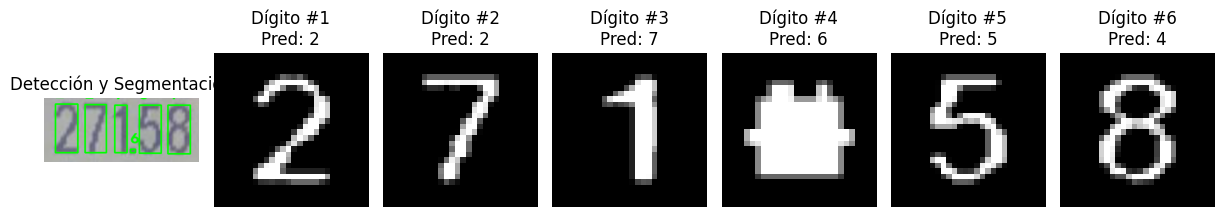


 RESULTADO FINAL UNIFICADO DE LA CIFRA
 Número Detectado Completo: 227654
 Confianza Promedio:         70.12%


In [8]:
import cv2
from google.colab import files
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

# 1. Subir la imagen con la cifra completa
uploaded_cifra = files.upload()

for filename in uploaded_cifra.keys():
    # 2. Leer la imagen en escala de grises usando OpenCV
    file_bytes = np.frombuffer(uploaded_cifra[filename], dtype=np.uint8)
    img_cv = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

    # Guardamos una copia para visualizar
    original_to_show = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    original_to_show = cv2.cvtColor(original_to_show, cv2.COLOR_BGR2RGB)

    # 3. Umbralización para binarizar la imagen (fondo negro, trazo blanco)
    # Si el fondo es blanco, invertimos los colores
    if img_cv[0, 0] > 127:
        _, thresh = cv2.threshold(img_cv, 127, 255, cv2.THRESH_BINARY_INV)
    else:
        _, thresh = cv2.threshold(img_cv, 127, 255, cv2.THRESH_BINARY)

    # 4. Encontrar contornos de los números
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filtrar y ordenar los contornos de izquierda a derecha según su posición X
    digit_bounding_boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        # Filtrar ruido pequeño
        if w > 5 and h > 5:
            digit_bounding_boxes.append((x, y, w, h))

    digit_bounding_boxes = sorted(digit_bounding_boxes, key=lambda b: b[0])

    # Arrays para guardar resultados individuales
    predicted_digits_list = []
    confidences_list = []
    segmented_images = []

    # 5. Procesar cada dígito detectado
    for x, y, w, h in digit_bounding_boxes:
        # Extraer la región de interés (ROI)
        roi = thresh[y:y+h, x:x+w]

        # Añadir un margen (padding) para que se parezca más al formato MNIST
        pad = max(w, h) // 4
        roi_padded = cv2.copyMakeBorder(roi, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)

        # Redimensionar a 28x28
        roi_resized = cv2.resize(roi_padded, (28, 28), interpolation=cv2.INTER_AREA)

        # Normalizar
        img_norm = roi_resized / 255.0
        img_input = np.expand_dims(img_norm, axis=0)

        # Predicción
        prediction_probs = model.predict(img_input, verbose=0)
        pred_digit = np.argmax(prediction_probs)
        confidence = np.max(prediction_probs) * 100

        predicted_digits_list.append(str(pred_digit))
        confidences_list.append(confidence)
        segmented_images.append(img_norm)

        # Dibujar cuadro de detección en la imagen original para visualización
        cv2.rectangle(original_to_show, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(original_to_show, str(pred_digit), (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # 6. Mostrar Resultados
    num_detected = len(digit_bounding_boxes)
    if num_detected > 0:
        plt.figure(figsize=(12, 5))

        # Mostrar la imagen completa con los contornos y detecciones
        plt.subplot(1, num_detected + 1, 1)
        plt.imshow(original_to_show)
        plt.title("Detección y Segmentación")
        plt.axis('off')

        # Mostrar cada segmento enviado al modelo
        for idx, img_seg in enumerate(segmented_images):
            plt.subplot(1, num_detected + 1, idx + 2)
            plt.imshow(img_seg, cmap='gray')
            plt.title(f"Dígito #{idx+1}\nPred: {predicted_digits_list[idx]}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

        # 7. Unificación de los Resultados en la cifra final
        final_number = "".join(predicted_digits_list)
        avg_confidence = np.mean(confidences_list)

        print("\n" + "="*60)
        print(f" RESULTADO FINAL UNIFICADO DE LA CIFRA")
        print("="*60)
        print(f" Número Detectado Completo: {final_number}")
        print(f" Confianza Promedio:         {avg_confidence:.2f}%")
        print("="*60)
    else:
        print("No se lograron detectar dígitos en la imagen subida.")